## ♻️ Removed Heuristics

**Concepts:** [Constructive heuristics](../routers.md#constructive-heuristics)

The heuristic entry points `EW_presolver`, `ClassicEW`, `CPEW`, `NBEW`, and `OBEW` were **removed** in _OptiWindNet_ version **v0.3.0**. Their closest replacements are methods of the unified heuristic entry point [constructor](../autoapi/optiwindnet/heuristics/index.rst#optiwindnet.heuristics.constructor).

The entry points `ClassicEW`, `CPEW`, `NBEW`, and `OBEW` took the location graph **L** as input and returned the embedded routeset **G** directly. The [constructor](../autoapi/optiwindnet/heuristics/index.rst#optiwindnet.heuristics.constructor) entry point operates instead on the available links graph **A** and returns a solution topology **S**, with a similar usage to that of `EW_presolver`.

The usage pattern is as the following snippet:

```python
P, A = make_planar_embedding(L)
S = constructor(A, capacity, method=..., straight_feeder_route=..., weigh_detours=...)
G = PathFinder(G_from_S(S, A), P, A).create_detours()
```

| Old Entry Point | **method** | **straight_feeder_route** | **weigh_detours** |
| :-: | :-: | :-: | :-: |
| `EW_presolver` | `'biased_EW'` | False | False |
| `ClassicEW` | `'esau_williams'` | False | False |
| `CPEW` | `'biased_EW'` | True | False |
| `NBEW` | `'radial_EW'` | True | False |
| `OBEW` | `'biased_EW'` | False | True |
| `OBEW` | `'rootlust'` | False | True |

> Note: to match the default _rootlust_ mode of OBEW, [constructor](../autoapi/optiwindnet/heuristics/index.rst#optiwindnet.heuristics.constructor) must be given the additional argument `rootlust_=(0.0, 0.6 * (capacity - 1) / capacity)`

The unified heuristic does not reproduce exactly the results of the deprecated heuristics, but the solution properties should match.

In [1]:
from optiwindnet.heuristics import constructor
from optiwindnet.importer import load_repository
from optiwindnet.interarraylib import G_from_S
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.pathfinding import PathFinder
from optiwindnet.svg import svgplot

In [2]:
locations = load_repository()

### EW_presolver – Esau-Williams pre-solver

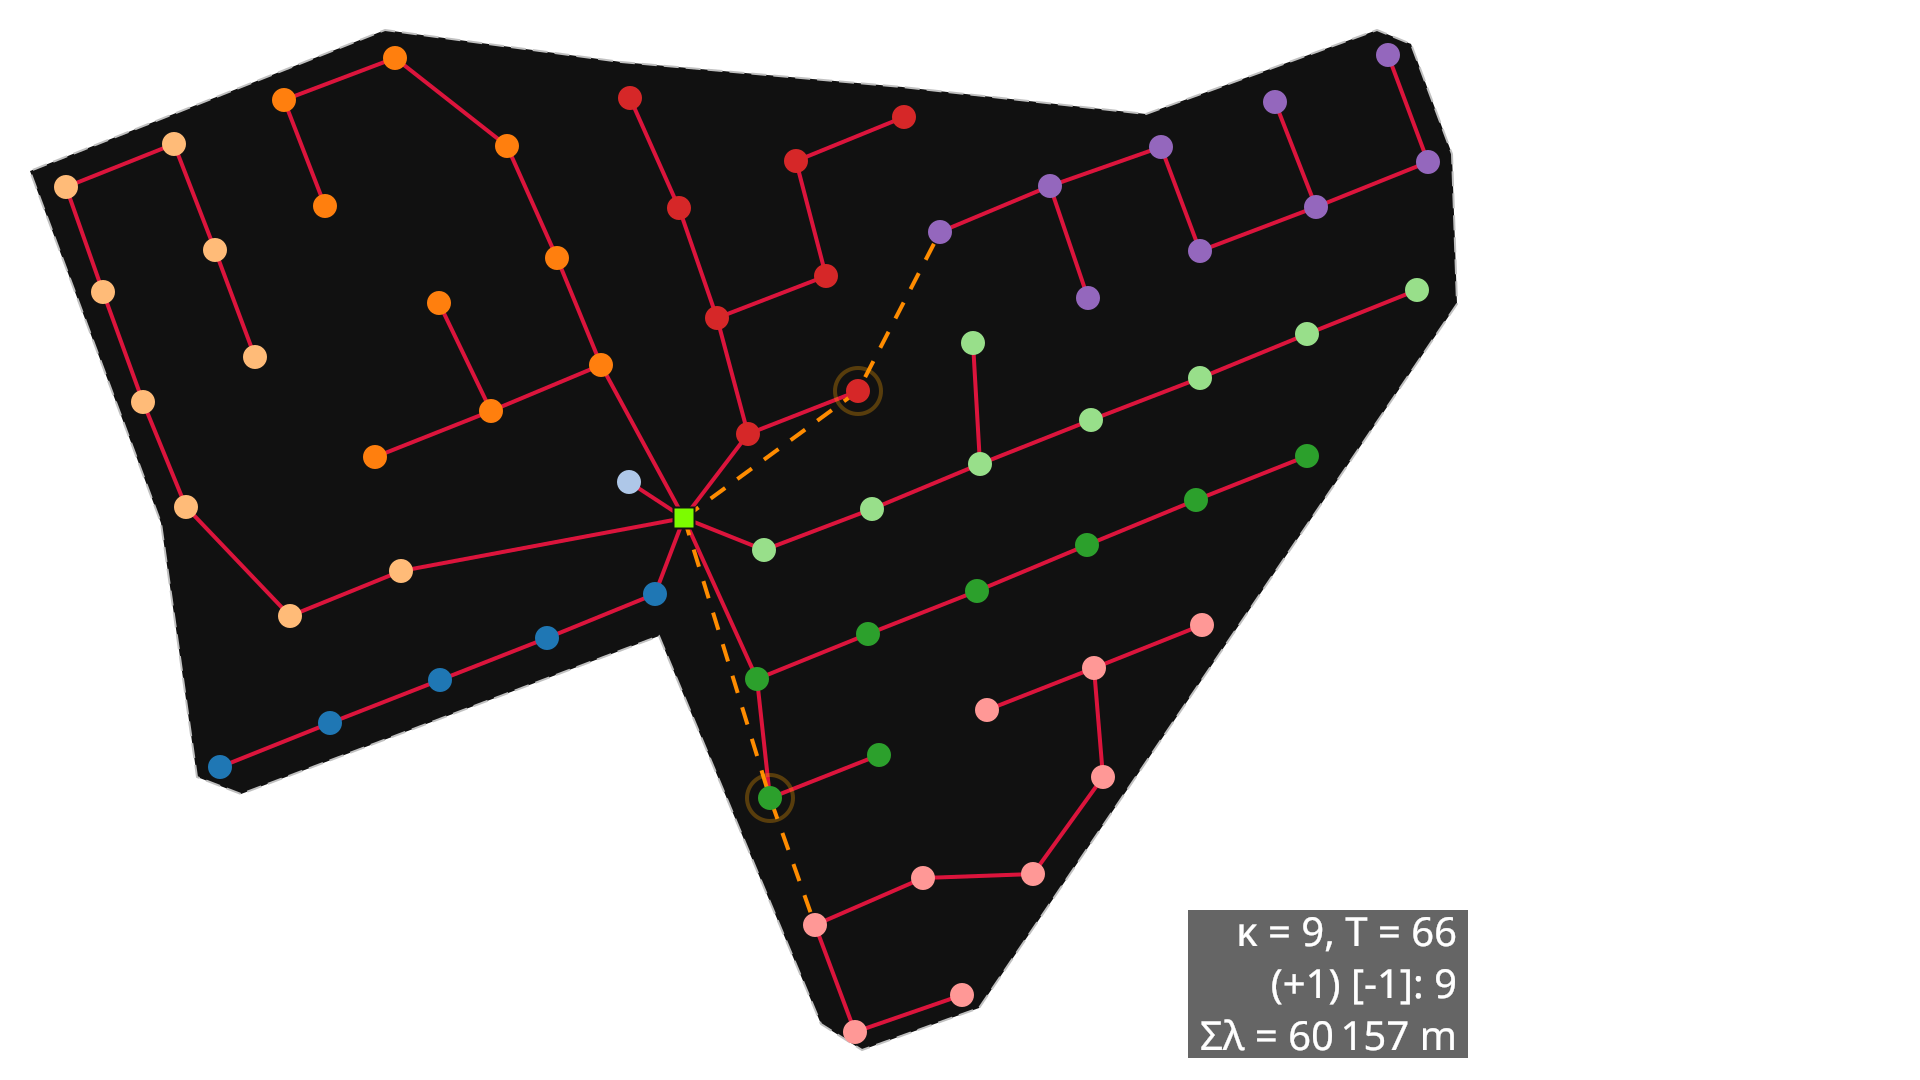

In [3]:
P, A = make_planar_embedding(locations.merkur)
S = constructor(
    A,
    capacity=9,
    method='biased_EW',
    weigh_detours=False,
)
G = PathFinder(G_from_S(S, A), P, A).create_detours()
svgplot(G)

### ClassicEW – Classic Esau-Williams

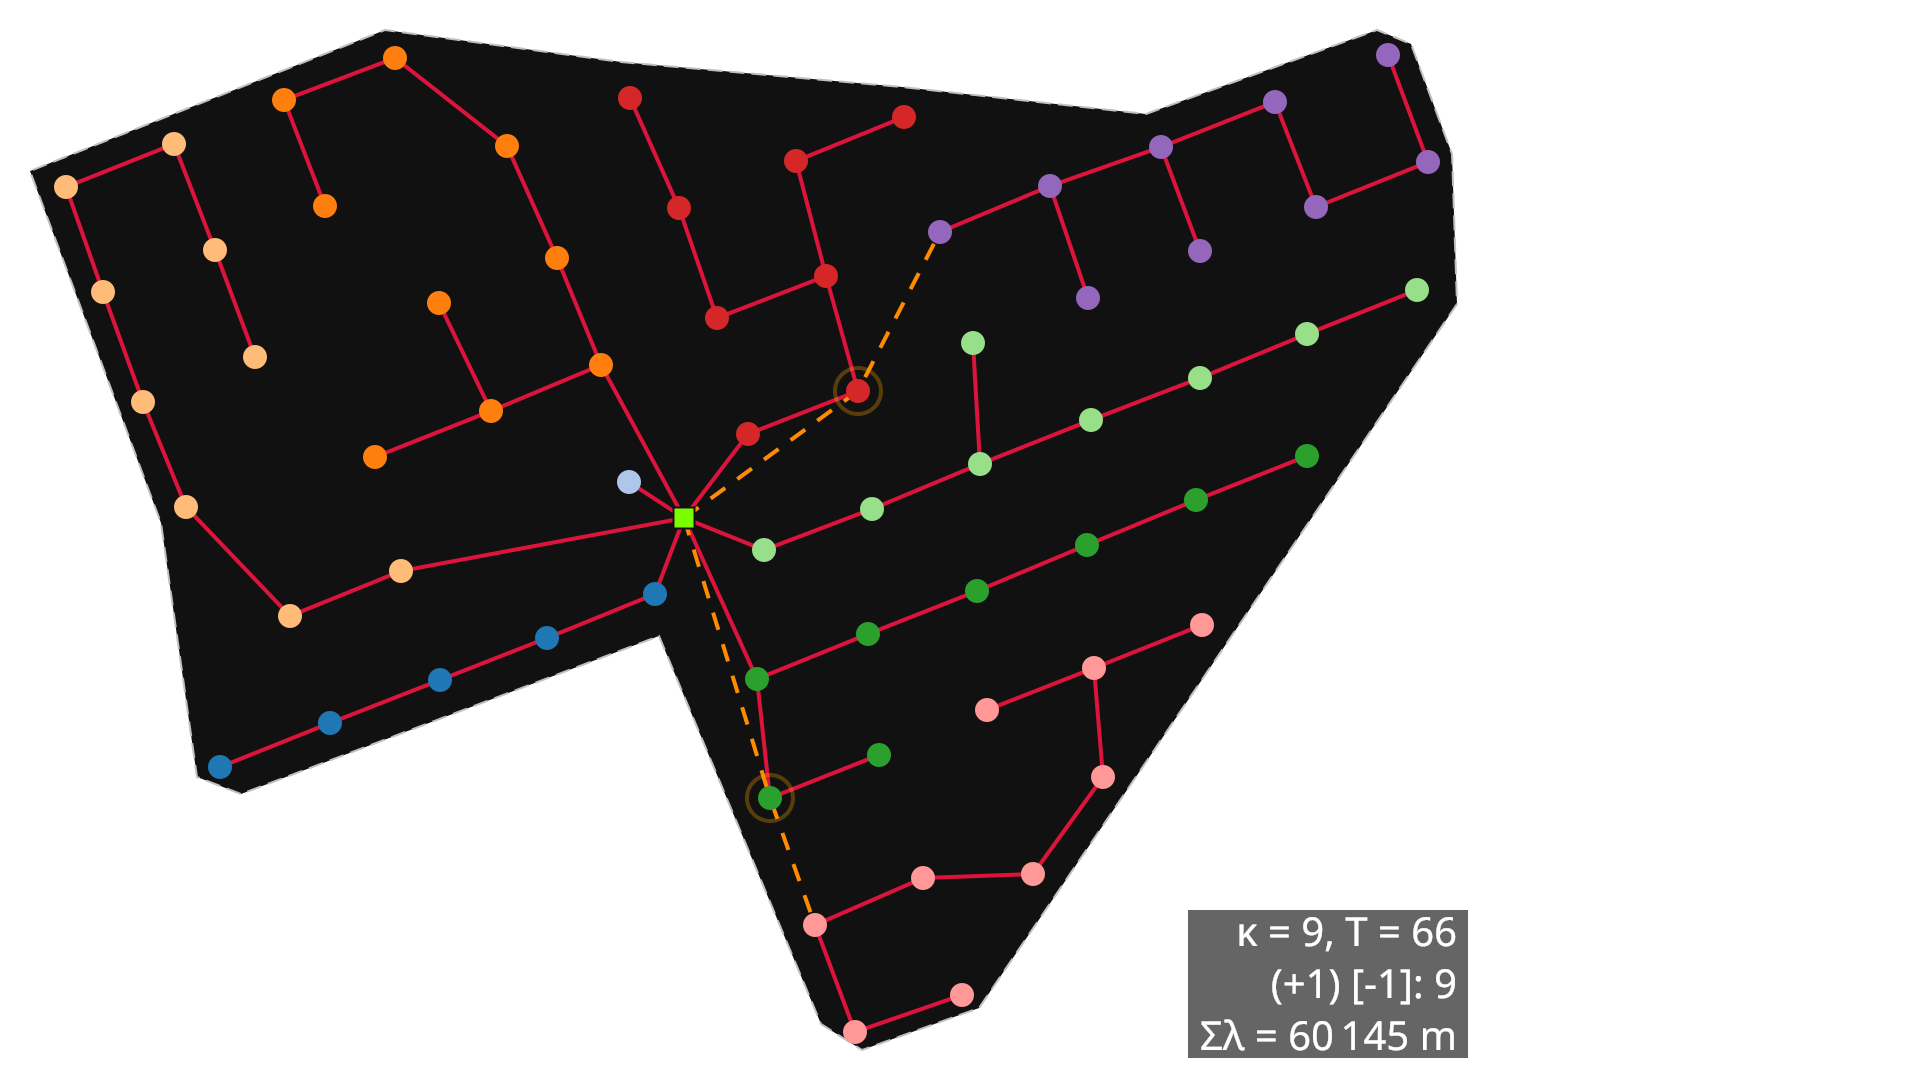

In [4]:
P, A = make_planar_embedding(locations.merkur)
S = constructor(
    A,
    capacity=9,
    method='esau_williams',
    weigh_detours=False,
)
G = PathFinder(G_from_S(S, A), P, A).create_detours()
svgplot(G)

### CPEW – Crossing-Preventing EW

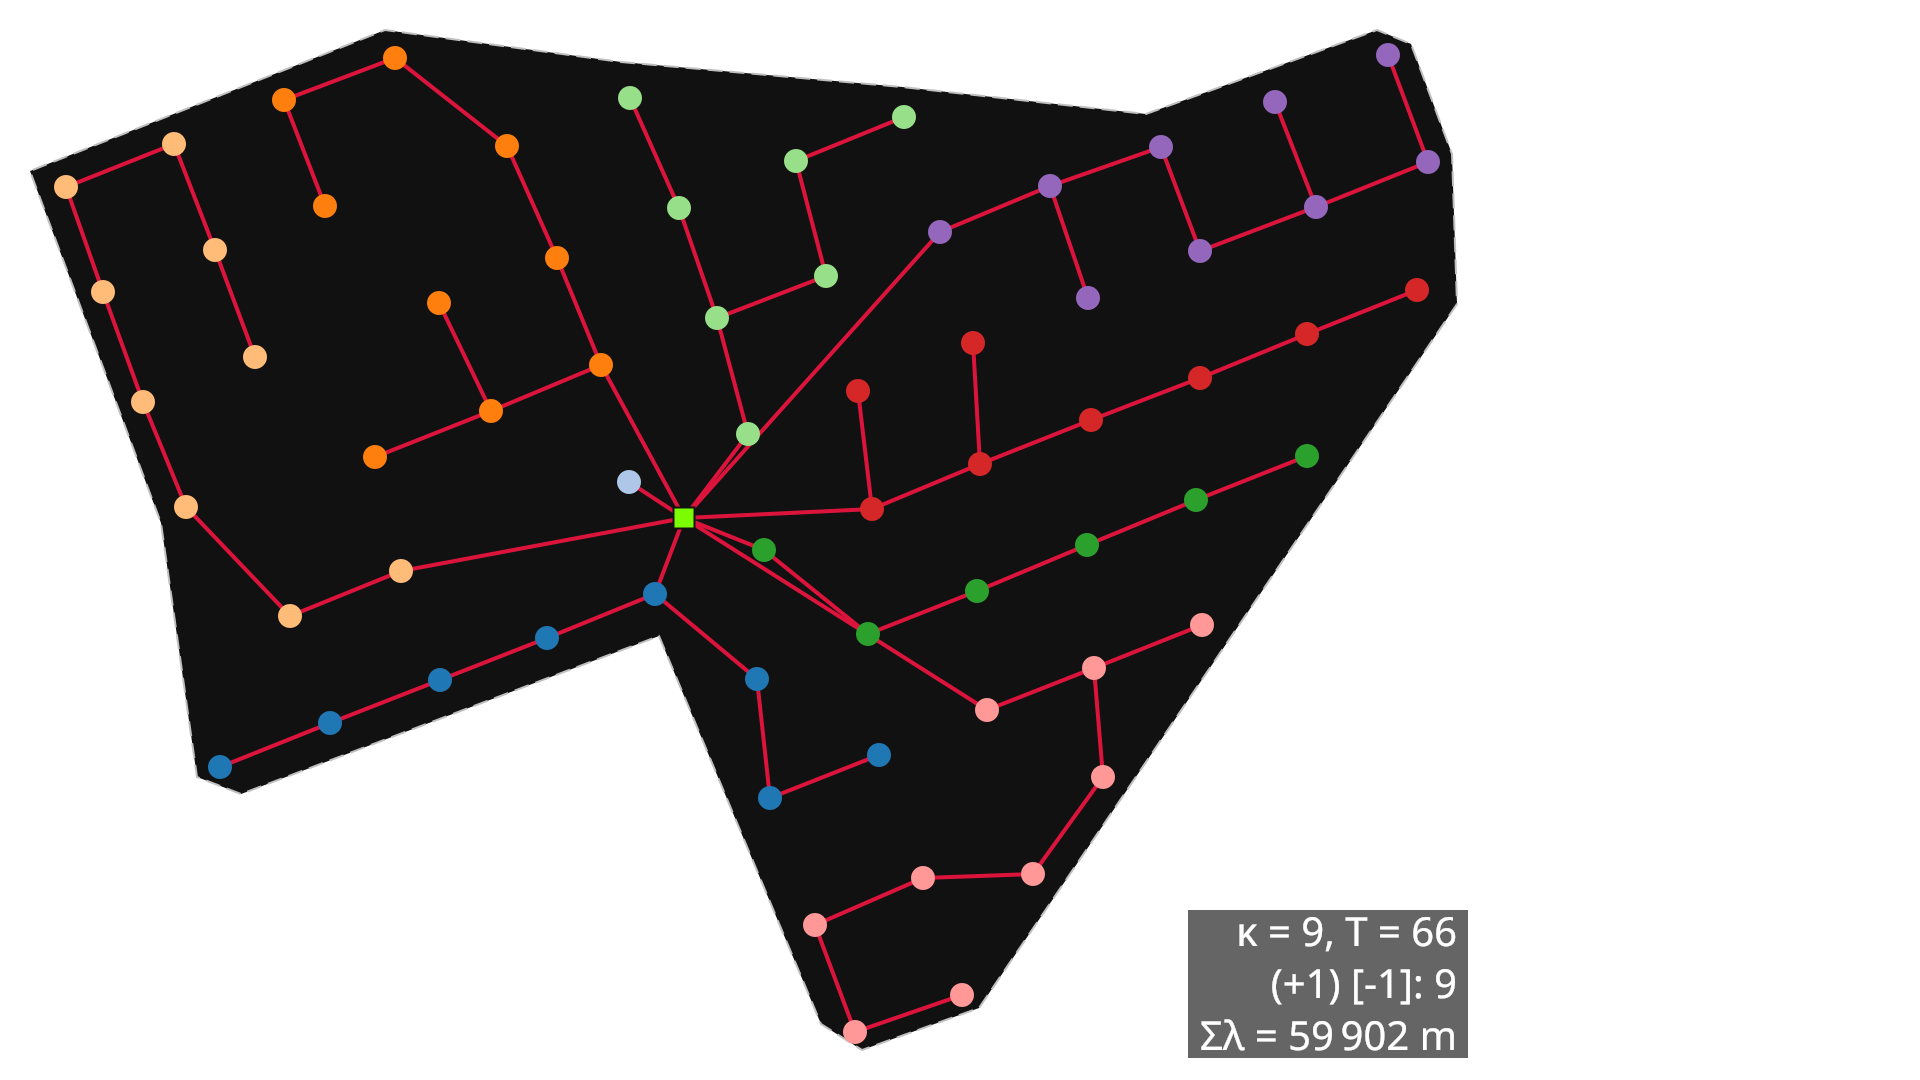

In [5]:
P, A = make_planar_embedding(locations.merkur)
S = constructor(
    A,
    capacity=9,
    method='biased_EW',
    straight_feeder_route=True,
    weigh_detours=False,
)
G = PathFinder(G_from_S(S, A), P, A).create_detours()
svgplot(G)

### NBEW - Non-Branching EW

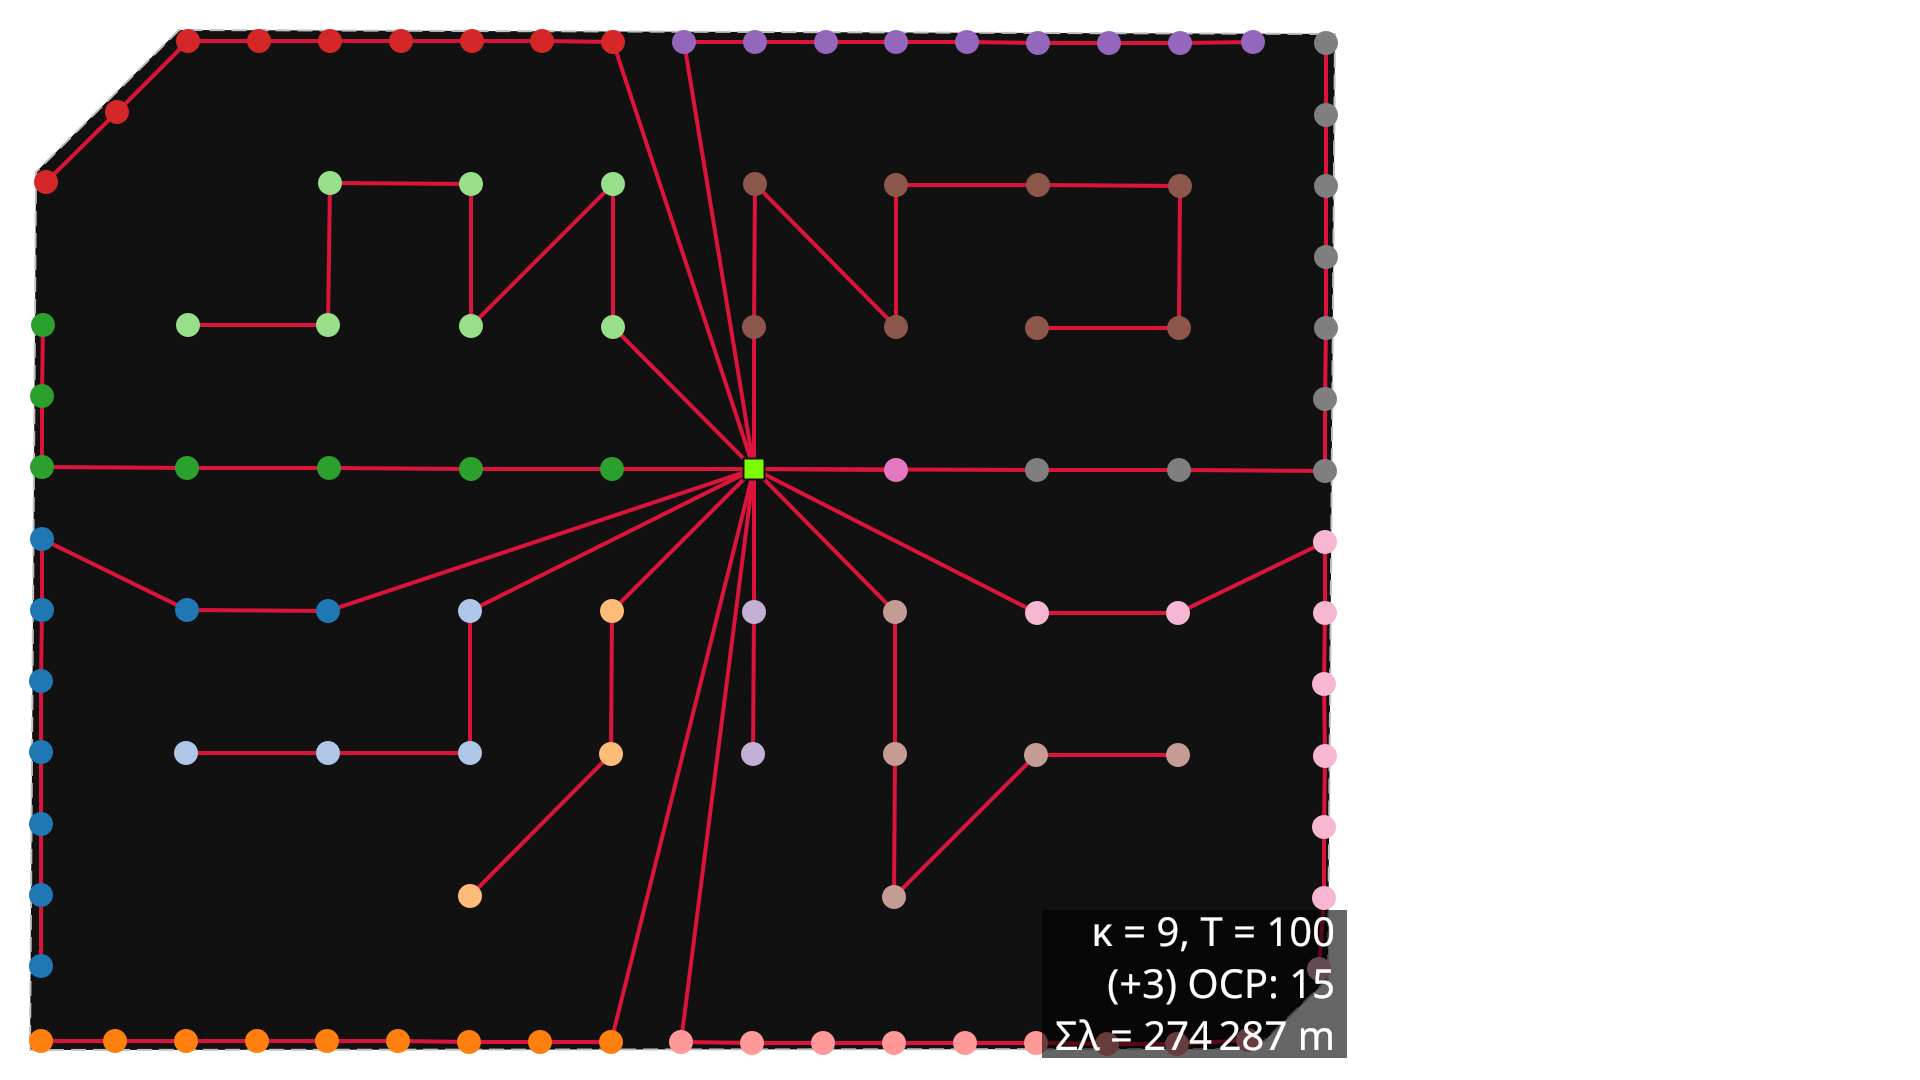

In [6]:
P, A = make_planar_embedding(locations.sofia)
S = constructor(
    A,
    capacity=9,
    method='radial_EW',
    straight_feeder_route=True,
    weigh_detours=False,
)
G = PathFinder(G_from_S(S, A), P, A).create_detours()
svgplot(G)

### OBEW – Obstacle-Bypassing EW

Regular OBEW

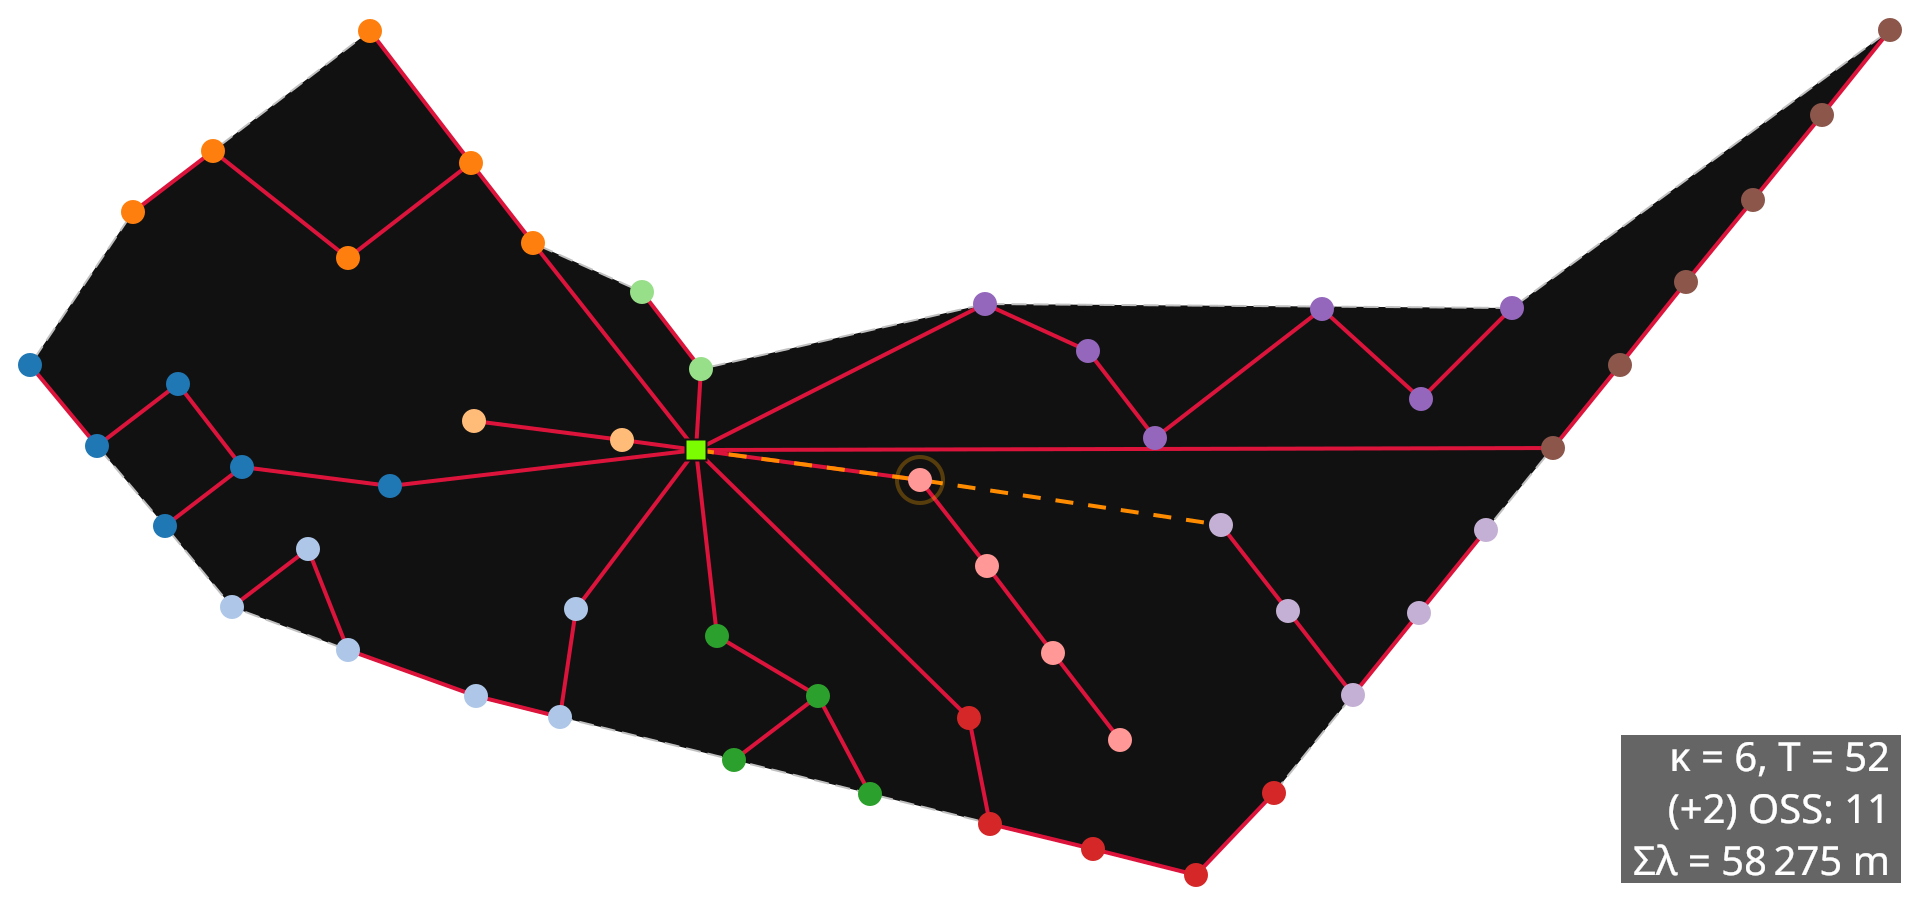

In [7]:
P, A = make_planar_embedding(locations.borkum2)
S = constructor(
    A,
    capacity=6,
    method='biased_EW',
)
G = PathFinder(G_from_S(S, A), P, A).create_detours()
svgplot(G)

Rootlust OBEW

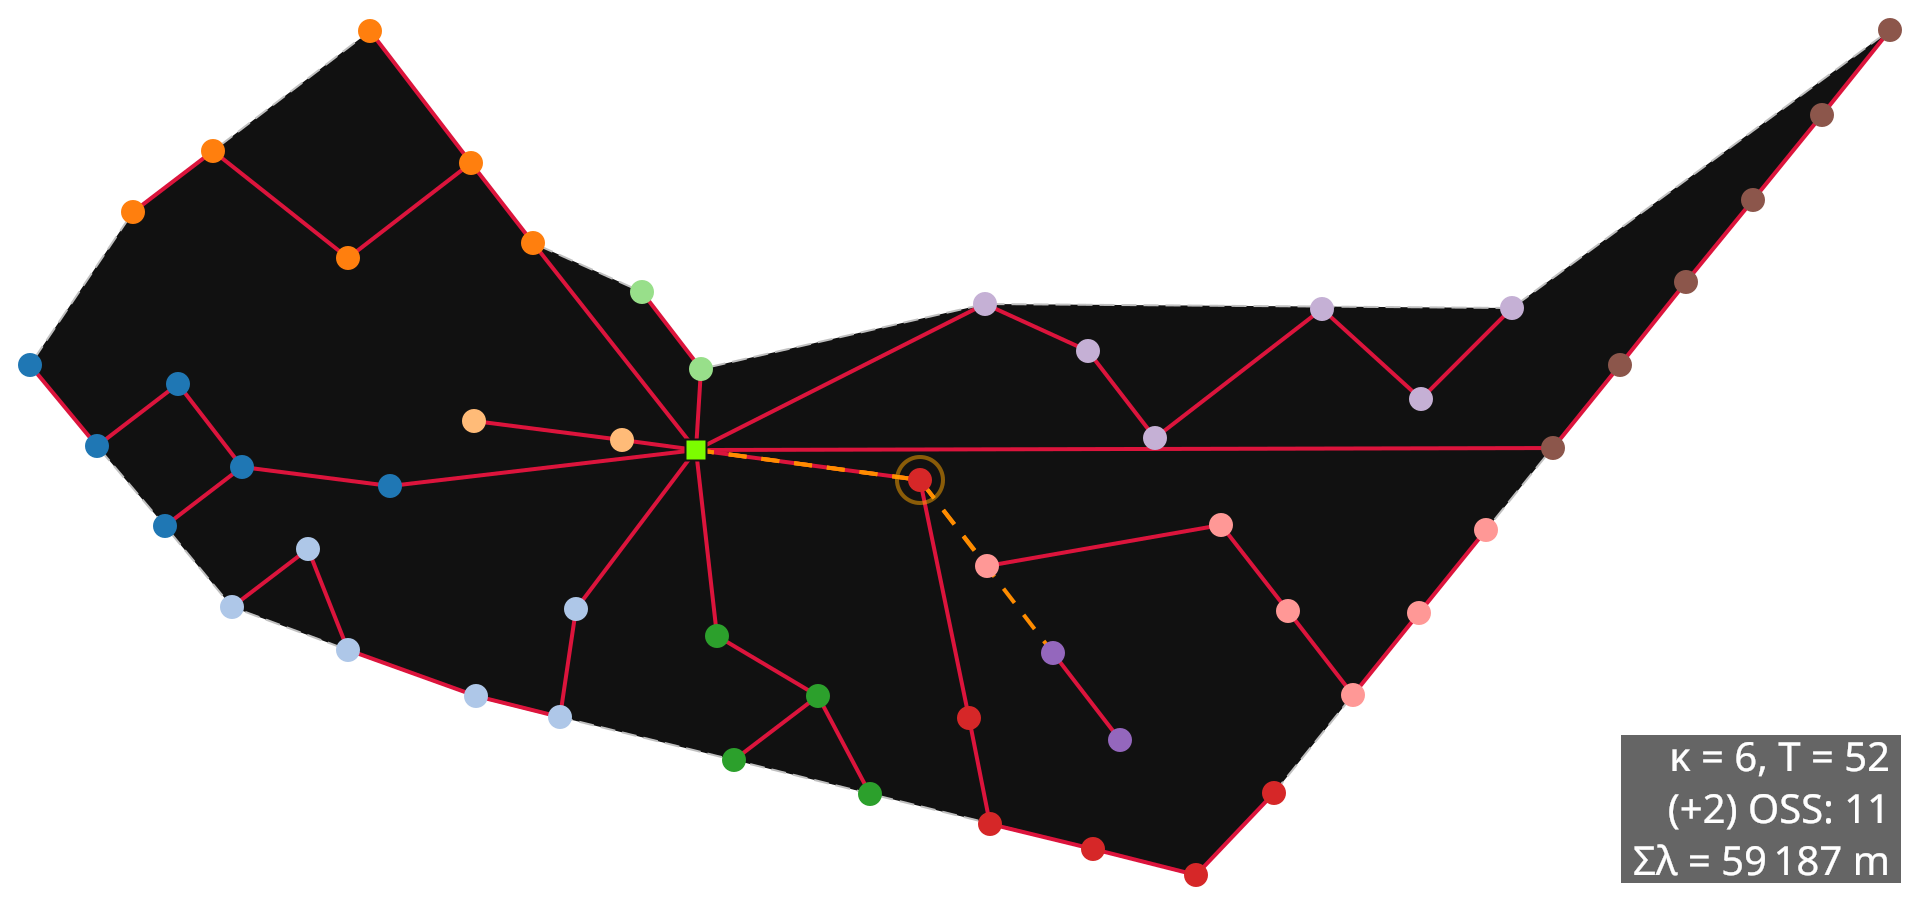

In [8]:
P, A = make_planar_embedding(locations.borkum2)
capacity = 6
S = constructor(
    A,
    capacity=capacity,
    method='rootlust',
    rootlust_=(0.0, 0.6 * (capacity - 1) / capacity),
)
G = PathFinder(G_from_S(S, A), P, A).create_detours()
svgplot(G)